In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
import glob

csv_folder = "/content/drive/MyDrive/Arhiva/Master/2 - drugi semestar/multimedijalni sistemi/[MMS] projekat/rezultati"

csv_files = glob.glob(os.path.join(csv_folder, "*.csv"))

print("Found CSV files:", len(csv_files))
for f in csv_files:
    print(f)

Found CSV files: 0


In [5]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt


experiments = {
    "T250 K4096\n20 images": "ddcm_metrics_per_image_T250_K4096_20images.csv",
    "T500 K4096\n20 images": "ddcm_metrics_per_image_T500_K4096_20images.csv",
    "T1000 K256\n5 images": "ddcm_metrics_per_image_T1000_K256_5images.csv",
    "T1000 K1024\n5 images": "ddcm_metrics_per_image_T1000_K1024.csv",
    "T1000 K2048\nM2 C3": "ddcm_metrics_per_image_T1000_K2048_M2_C3.csv",
    "T1000 K8192\n5 images": "ddcm_metrics_per_image_T1000_K8192.csv",
}

# Provjera da li fajlovi postoje
for exp_name, filename in experiments.items():
    path = os.path.join(csv_folder, filename)
    print(exp_name, "->", "OK" if os.path.exists(path) else "MISSING", path)

T250 K4096
20 images -> OK /content/drive/MyDrive/Arhiva/Master/2 - drugi semestar/multimedijalni sistemi/[MMS] projekat/rezultati/ddcm_metrics_per_image_T250_K4096_20images.csv
T500 K4096
20 images -> OK /content/drive/MyDrive/Arhiva/Master/2 - drugi semestar/multimedijalni sistemi/[MMS] projekat/rezultati/ddcm_metrics_per_image_T500_K4096_20images.csv
T1000 K256
5 images -> OK /content/drive/MyDrive/Arhiva/Master/2 - drugi semestar/multimedijalni sistemi/[MMS] projekat/rezultati/ddcm_metrics_per_image_T1000_K256_5images.csv
T1000 K1024
5 images -> OK /content/drive/MyDrive/Arhiva/Master/2 - drugi semestar/multimedijalni sistemi/[MMS] projekat/rezultati/ddcm_metrics_per_image_T1000_K1024.csv
T1000 K2048
M2 C3 -> OK /content/drive/MyDrive/Arhiva/Master/2 - drugi semestar/multimedijalni sistemi/[MMS] projekat/rezultati/ddcm_metrics_per_image_T1000_K2048_M2_C3.csv
T1000 K8192
5 images -> OK /content/drive/MyDrive/Arhiva/Master/2 - drugi semestar/multimedijalni sistemi/[MMS] projekat/rezu

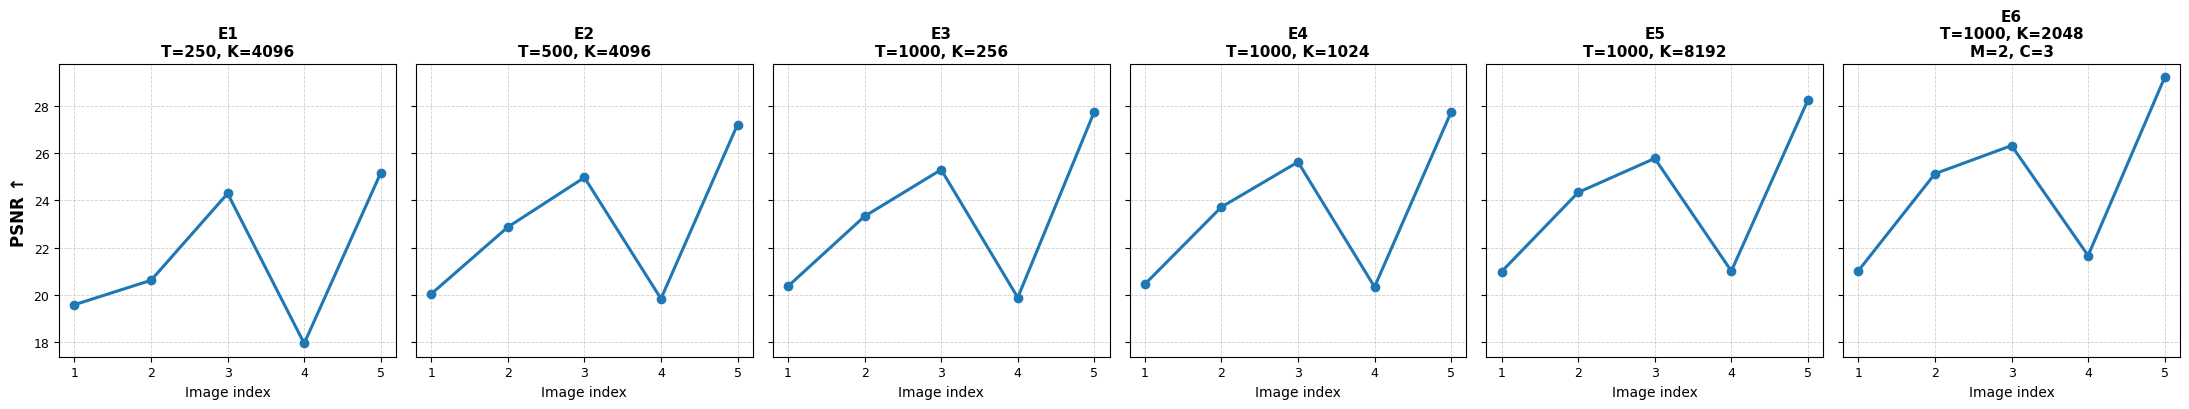

In [17]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Folder gdje su CSV fajlovi
# csv_folder = "/content/drive/MyDrive/ddcm_results"  # prilagodi ako treba

experiments = {
    "E1": "ddcm_metrics_per_image_T250_K4096_20images.csv",
    "E2": "ddcm_metrics_per_image_T500_K4096_20images.csv",
    "E3": "ddcm_metrics_per_image_T1000_K256_5images.csv",
    "E4": "ddcm_metrics_per_image_T1000_K1024.csv",
    "E5": "ddcm_metrics_per_image_T1000_K8192.csv",
    "E6": "ddcm_metrics_per_image_T1000_K2048_M2_C3.csv",
}

exp_details = {
    "E1": "T=250, K=4096",
    "E2": "T=500, K=4096",
    "E3": "T=1000, K=256",
    "E4": "T=1000, K=1024",
    "E5": "T=1000, K=8192",
    "E6": "T=1000, K=2048\nM=2, C=3",
}

fig, axes = plt.subplots(1, 6, figsize=(22, 4.2), sharey=True)

for ax, (exp_name, filename) in zip(axes, experiments.items()):
    path = os.path.join(csv_folder, filename)
    df = pd.read_csv(path).head(5)

    x = list(range(1, len(df) + 1))

    ax.plot(
        x,
        df["PSNR"],
        marker="o",
        linewidth=2.2,
        markersize=6
    )

    ax.set_title(f"{exp_name}\n{exp_details[exp_name]}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Image index", fontsize=10)
    ax.set_xticks(x)
    ax.tick_params(axis="both", labelsize=9)
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)

axes[0].set_ylabel("PSNR ↑", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("per_image_psnr_E1_E6_pretty.png", dpi=300, bbox_inches="tight")
plt.show()

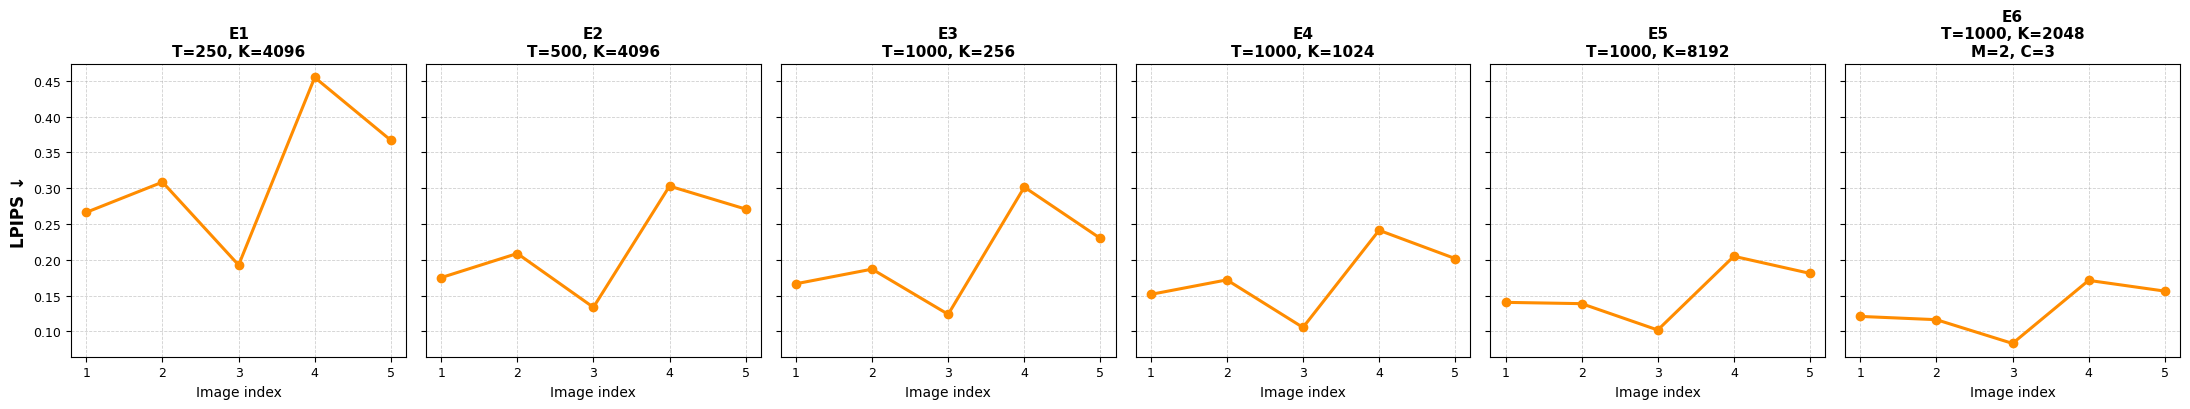

In [16]:
fig, axes = plt.subplots(1, 6, figsize=(22, 4.2), sharey=True)

for ax, (exp_name, filename) in zip(axes, experiments.items()):
    path = os.path.join(csv_folder, filename)
    df = pd.read_csv(path).head(5)

    x = list(range(1, len(df) + 1))

    ax.plot(
        x,
        df["LPIPS"],
        marker="o",
        linewidth=2.2,
        markersize=6,
        color="darkorange"
    )

    ax.set_title(f"{exp_name}\n{exp_details[exp_name]}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Image index", fontsize=10)
    ax.set_xticks(x)
    ax.tick_params(axis="both", labelsize=9)
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)

axes[0].set_ylabel("LPIPS ↓", fontsize=12, fontweight="bold")



plt.tight_layout()
plt.savefig("per_image_lpips_E1_E6_pretty.png", dpi=300, bbox_inches="tight")
plt.show()